<a href="https://colab.research.google.com/github/Dinhho1902/AI-For-Beginners/blob/main/Assignment_2_Data_Understanding_and_Preprocessing%2C_and_Exploratory_Data_Analysis_(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This code block is part of the Exploratory Data Analysis section. It starts by importing the pandas library, which is essential for data manipulation in Python. It then defines the file_location variable to point to the CSV file Loan_default.csv. Finally, it uses pd.read_csv() to load the data from this file into a pandas DataFrame named df, and display(df.head()) is used to show the first five rows of the DataFrame, giving us a quick preview of the data's structure and content.



In [3]:
#Exploratory Data Analysis
import pandas as pd

# Construct the full path to the CSV file
file_location = "/content/Loan_default.csv"
df = pd.read_csv(file_location)
display(df.head())


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


This is designed to give you a quick summary of your dataset abd a comprehensive summary, including the column names, the number of non-null values in each column, their data types (like integer, float, or object for strings), and the memory usage of the DataFrame.

In [4]:
# Check dataset shape and basic info
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()

Dataset Shape: (255347, 18)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner  

In [5]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


In [34]:
duplicate_rows = df[df.duplicated(keep=False)]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

Number of duplicate rows: 0


In [6]:
# Display basic statistical summary
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


This is designed to visualize the percentage distribution of the 'Default' column in your DataFrame

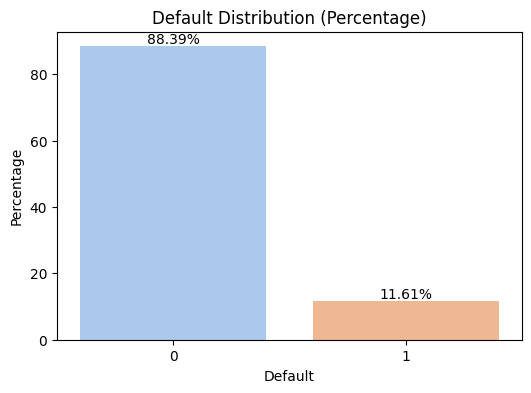

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
# Target distribution
def plot_target_distribution(df):
  plt.figure(figsize=(6,4))

# Calculate percentage
  default_counts = df['Default'].value_counts()
  default_percentages = default_counts / len(df) * 100

# Create the bar plot
  ax = sns.barplot(x=default_percentages.index, y=default_percentages.values, hue=default_percentages.index, palette='pastel', legend=False)
  plt.title("Default Distribution (Percentage)")
  plt.xlabel("Default")
  plt.ylabel("Percentage")
  plt.xticks(rotation=0) # Keep x-ticks horizontal as there are only two categories

# Annotate percentages on bars

  for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
      (p.get_x() + p.get_width() / 2., p.get_height()),
      ha='center', va='bottom')
  plt.show()

plot_target_distribution(df)

This code is designed to visualize the distribution of all numerical columns in your DataFrame df using histograms and Kernel Density Estimates (KDEs)

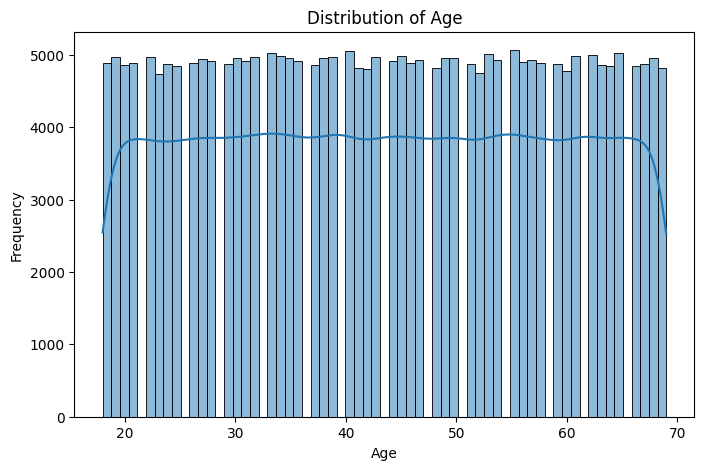

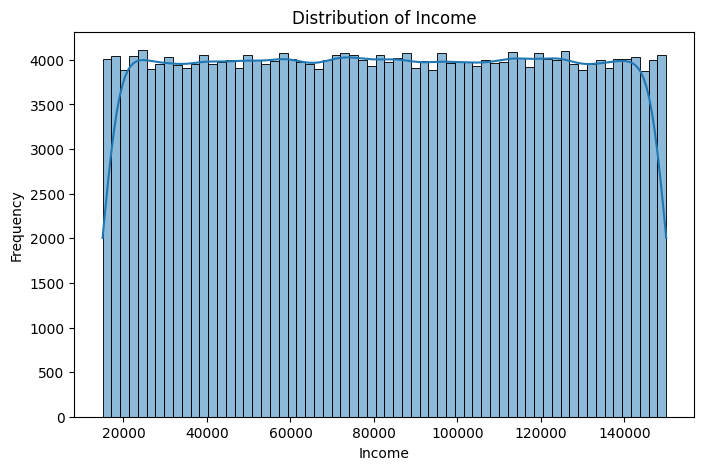

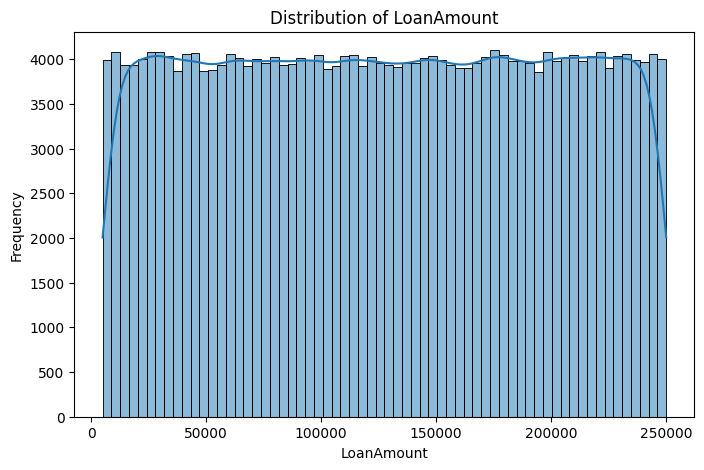

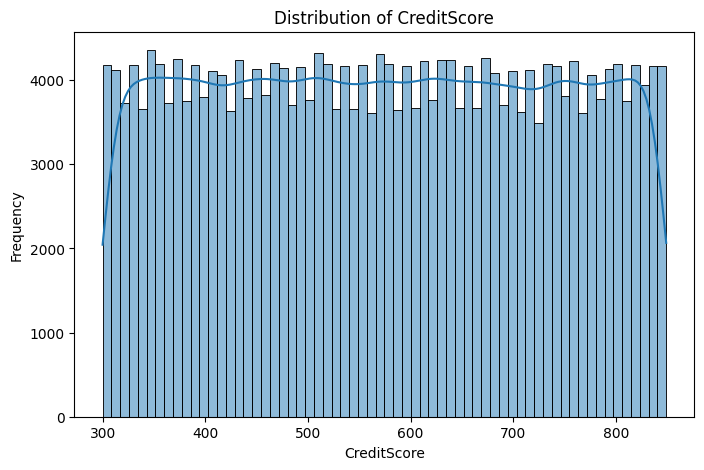

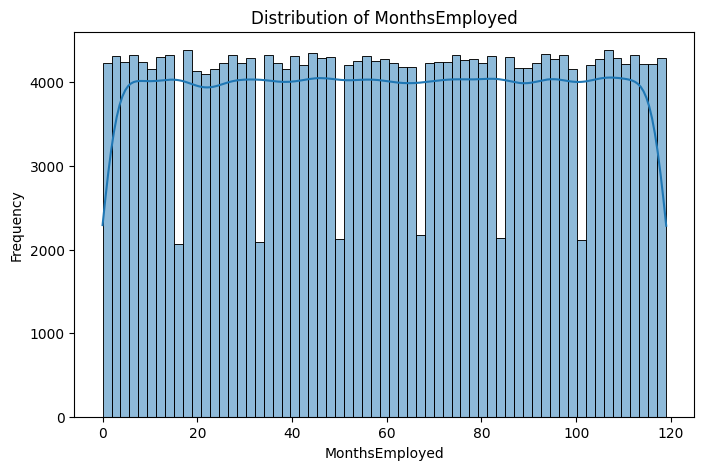

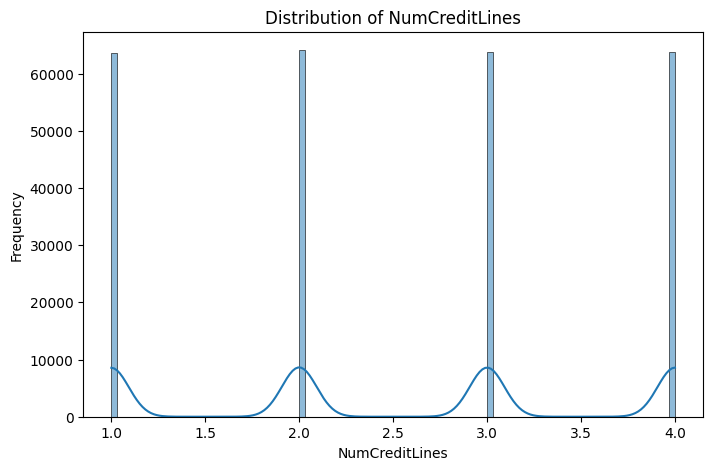

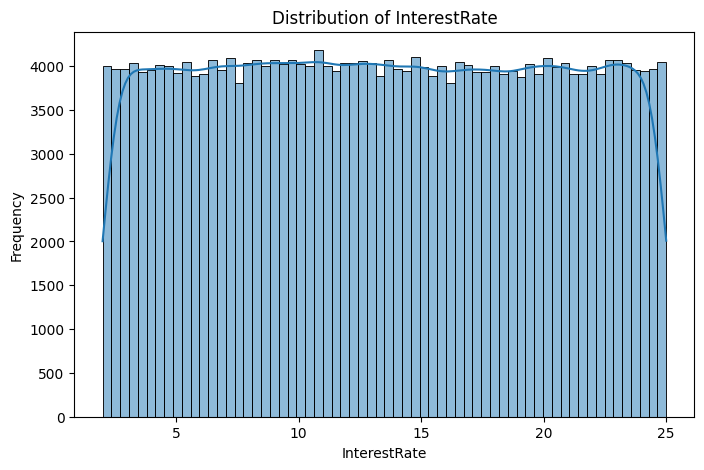

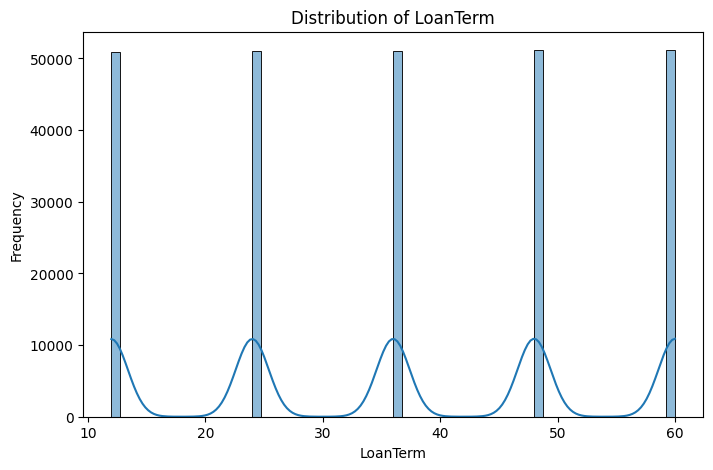

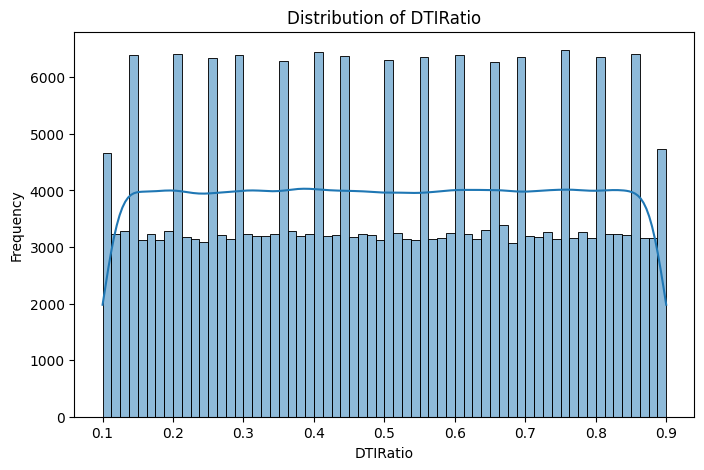

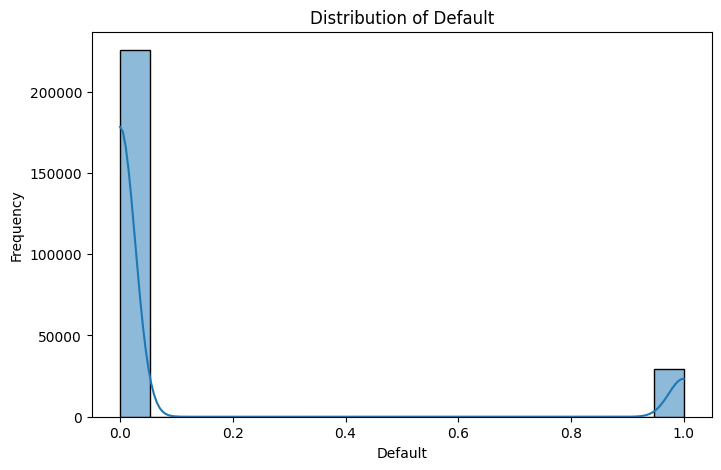

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
# Plot distributions of numerical columns
for col in numerical_cols:
  plt.figure(figsize=(8, 5))
  sns.histplot(data=df, x=col, kde=True)
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.show()

This part is designed to visualize the percentage distribution of categorical features in your DataFrame df using custom bar plots

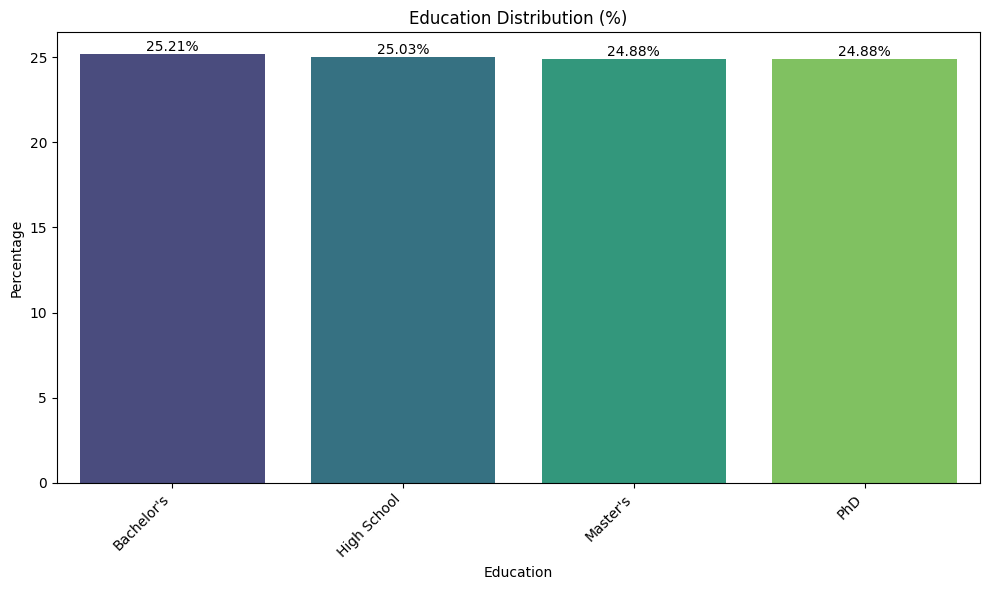

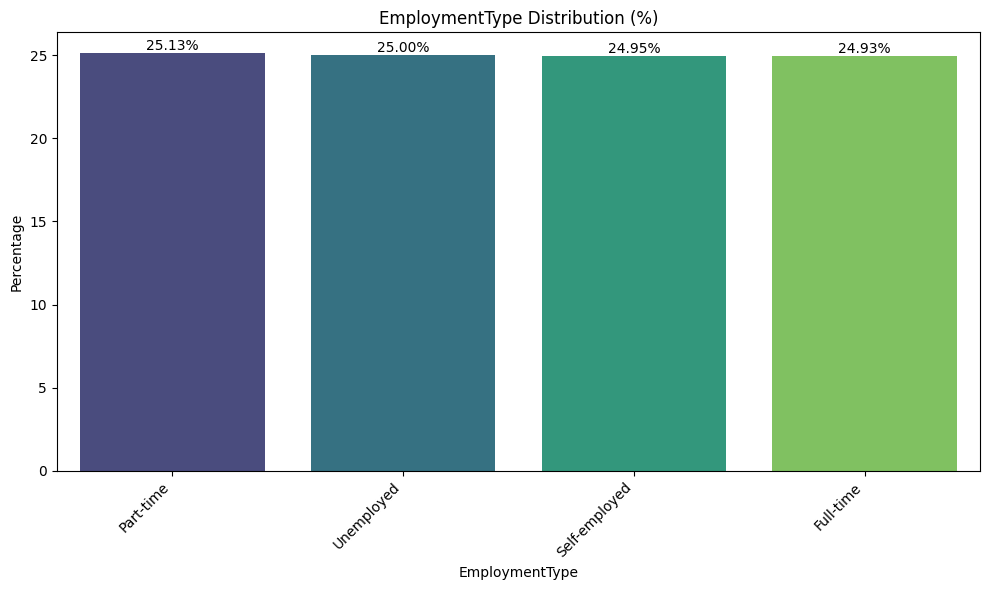

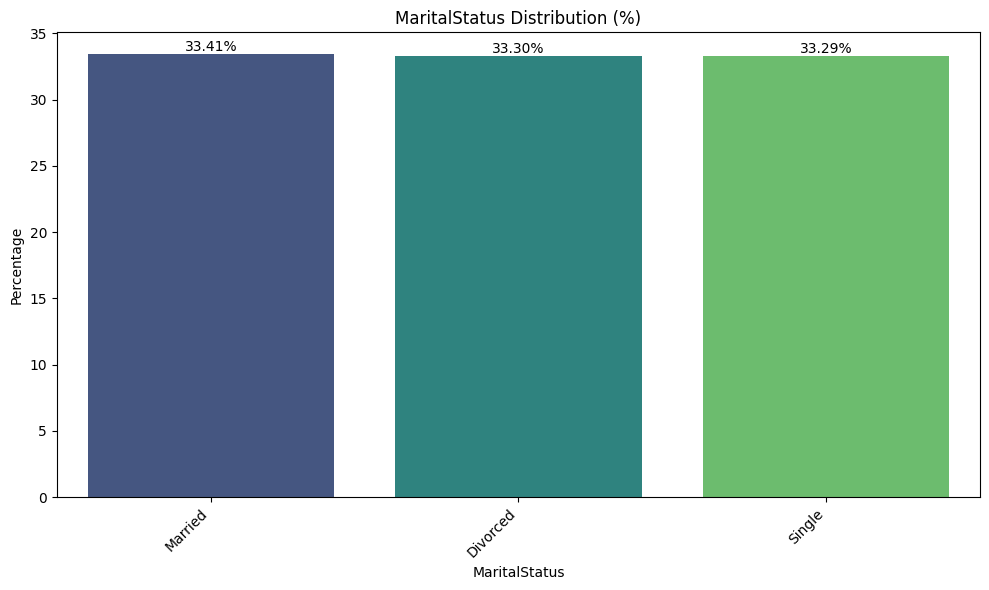

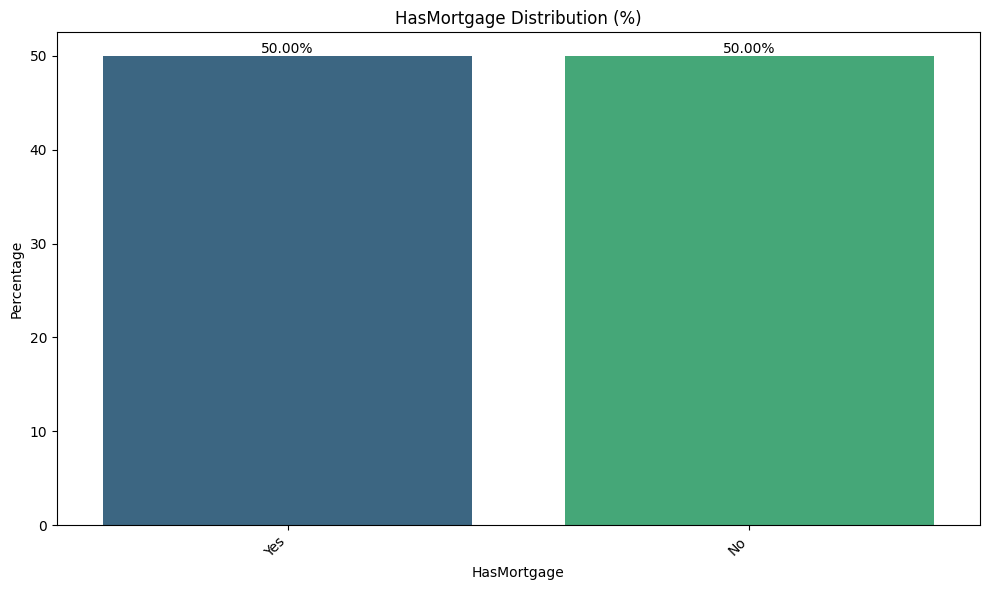

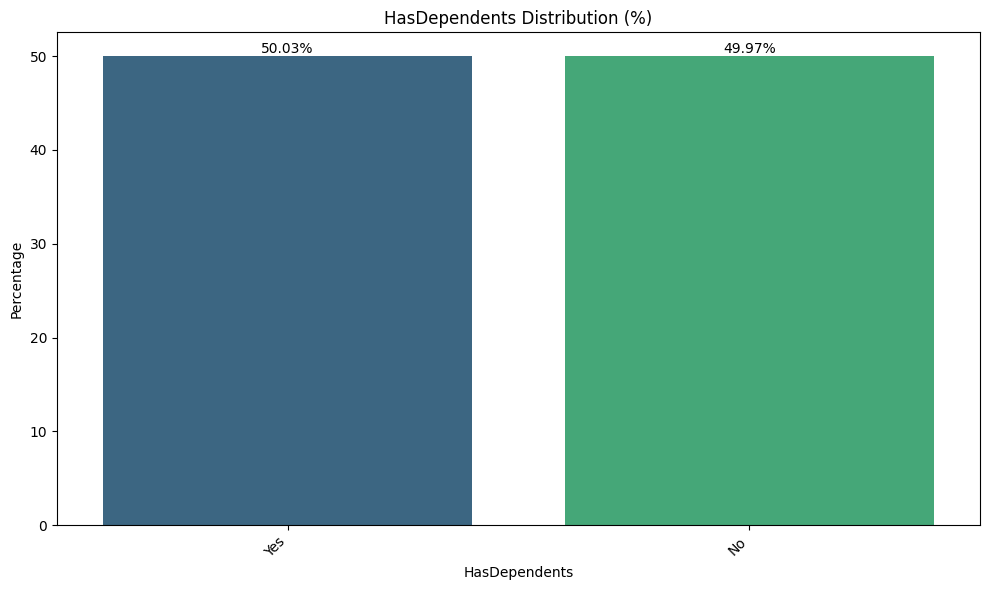

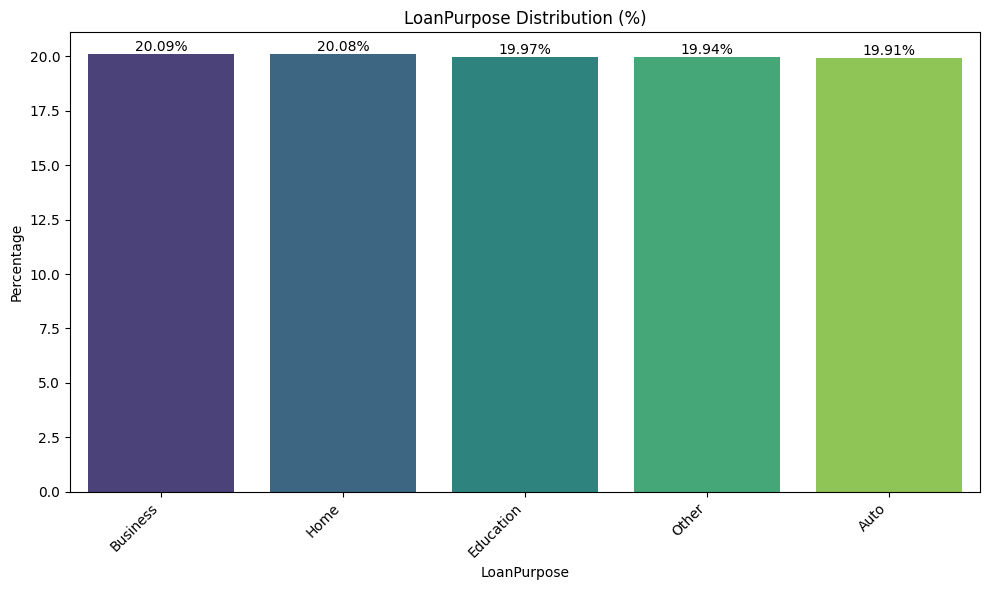

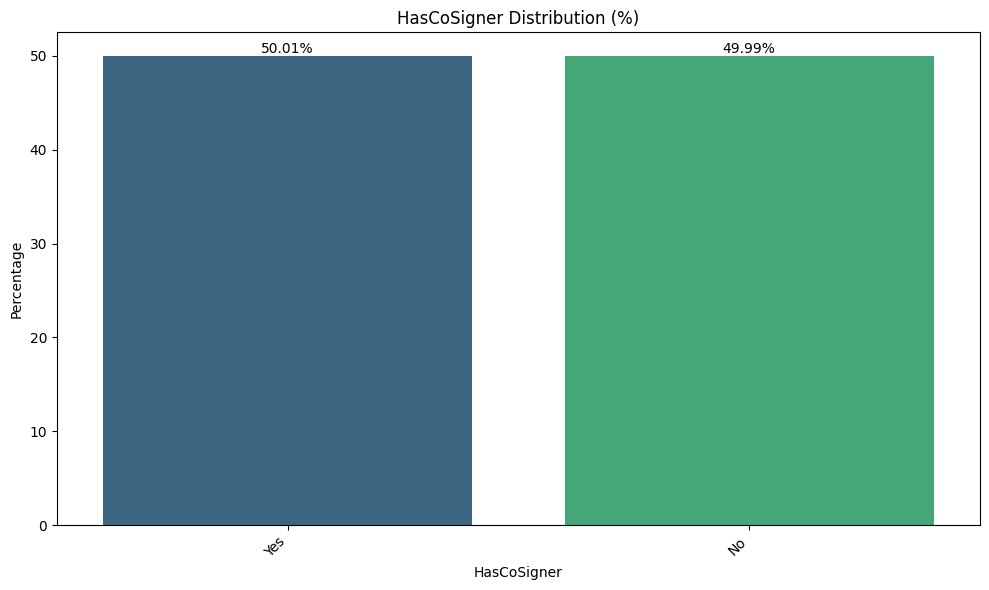

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
# Define a function to plot percentage bar plots for categorical features
def plot_percentage_bar(df, col, title):
  plt.figure(figsize=(10, 6))
# Calculate percentage
  category_counts = df[col].value_counts()
  category_percentages = category_counts / len(df) * 100
# Create the bar plot
  ax = sns.barplot(x=category_percentages.index, y=category_percentages.values, hue=category_percentages.index, palette='viridis', legend=False)
  plt.title(title)
  plt.xlabel(col)
  plt.ylabel("Percentage")
  plt.xticks(rotation=45, ha='right') # Rotate x-ticks for better readability
# Annotate percentages on bars
  for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
    (p.get_x() + p.get_width() / 2., p.get_height()),ha='center', va='bottom')
  plt.tight_layout() # Adjust layout to prevent labels overlapping
  plt.show()

# Select categorical columns (excluding 'LoanID' as it's an identifier)
categorical_cols = df.drop(columns = ['LoanID']).select_dtypes(include = ['object']).columns

# Plot percentage distribution for each categorical column
for col in categorical_cols:
  plot_percentage_bar(df, col, f'{col} Distribution (%)')

We are visualizing the correlation between all numerical features in your DataFrame df using a heatmap

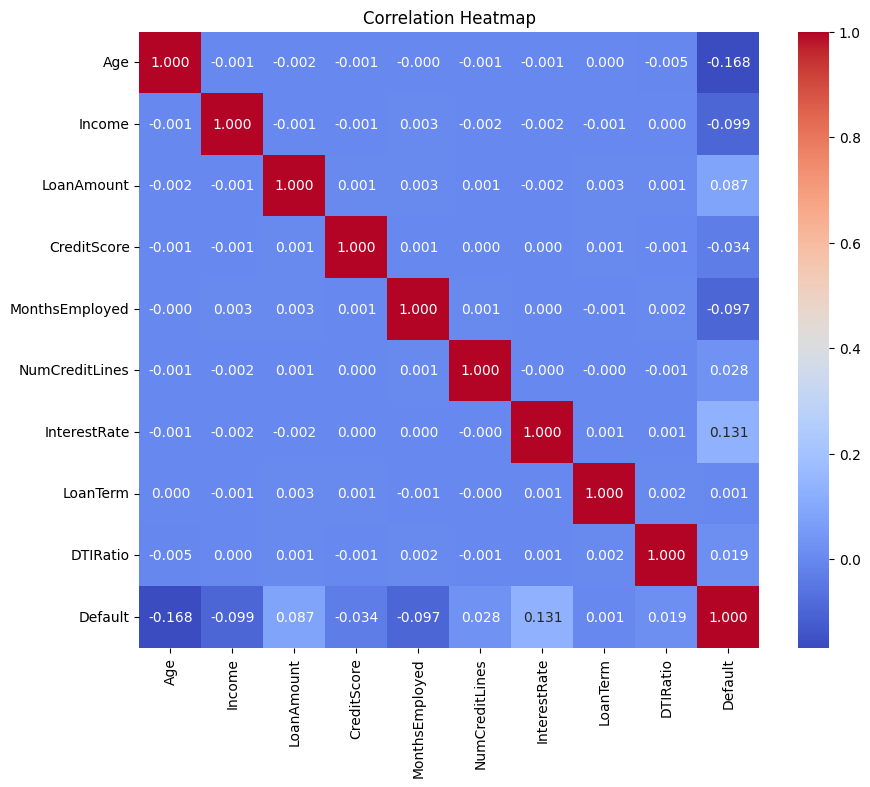

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
# Calculate the correlation matrix for numerical columns
correlation_matrix = df[numerical_cols].corr()
# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation Heatmap')
plt.show()

In [24]:
from scipy.stats import chi2_contingency
import numpy as np
# Select categorical columns (excluding 'LoanID' as it's an identifier)
categorical_cols = df.drop(columns=['LoanID']).select_dtypes(include=['object']).columns
# Perform Chi-Squared test for each categorical column against 'Default'
chi2_results = {}
for col in categorical_cols:
  contingency_table = pd.crosstab(df[col], df['Default'])
  chi2, p, dof, expected = chi2_contingency(contingency_table)
  chi2_results[col] = {'Chi2 Statistic': chi2, 'p-value': p}
# Display the results
print("Chi-Squared Test Results for Categorical Features vs. Default:")

for col, results in chi2_results.items():
  print(f"\n{col}:")
  print(f" Chi2 Statistic: {results['Chi2 Statistic']:.4f}")
  print(f" p-value: {results['p-value']:.4f}")
  # Interpret p-value
  alpha = 0.05
  if results['p-value'] < alpha:
    print(f" Result: Statistically significant association with Default (reject null hypothesis)")
  else:
    print(f" Result: No statistically significant association with Default (fail to reject null hypothesis)")

Chi-Squared Test Results for Categorical Features vs. Default:

Education:
 Chi2 Statistic: 214.0190
 p-value: 0.0000
 Result: Statistically significant association with Default (reject null hypothesis)

EmploymentType:
 Chi2 Statistic: 529.7449
 p-value: 0.0000
 Result: Statistically significant association with Default (reject null hypothesis)

MaritalStatus:
 Chi2 Statistic: 200.3611
 p-value: 0.0000
 Result: Statistically significant association with Default (reject null hypothesis)

HasMortgage:
 Chi2 Statistic: 133.2520
 p-value: 0.0000
 Result: Statistically significant association with Default (reject null hypothesis)

HasDependents:
 Chi2 Statistic: 306.8506
 p-value: 0.0000
 Result: Statistically significant association with Default (reject null hypothesis)

LoanPurpose:
 Chi2 Statistic: 127.9342
 p-value: 0.0000
 Result: Statistically significant association with Default (reject null hypothesis)

HasCoSigner:
 Chi2 Statistic: 390.3050
 p-value: 0.0000
 Result: Statistically 

### Visualizing Categorical Features vs. Default

To further explore the relationships identified by the Chi-Squared tests, let's visualize the proportion of defaults within each category for every categorical feature. This will help us understand the patterns of default rates across different segments of our data.

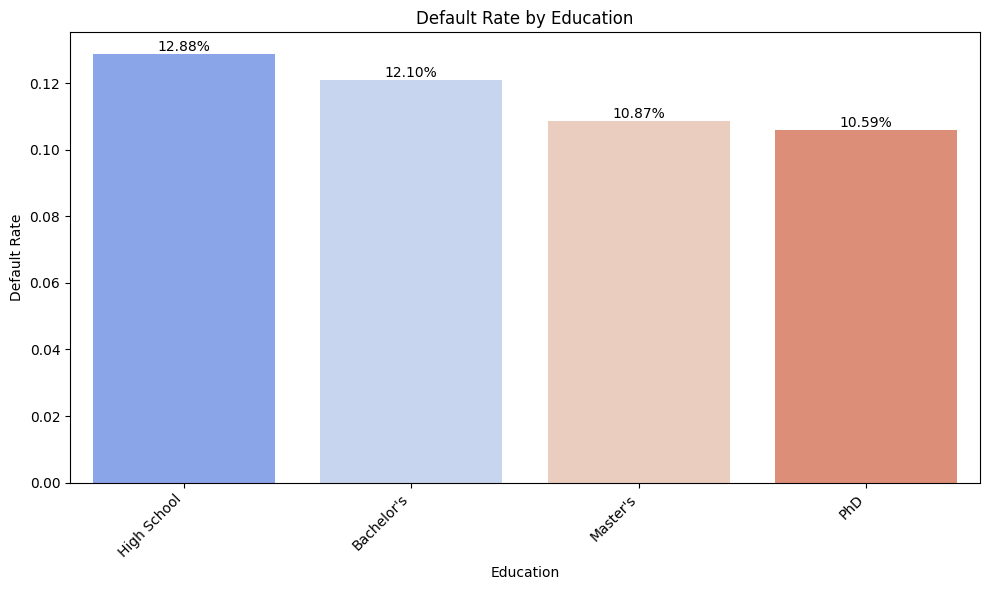

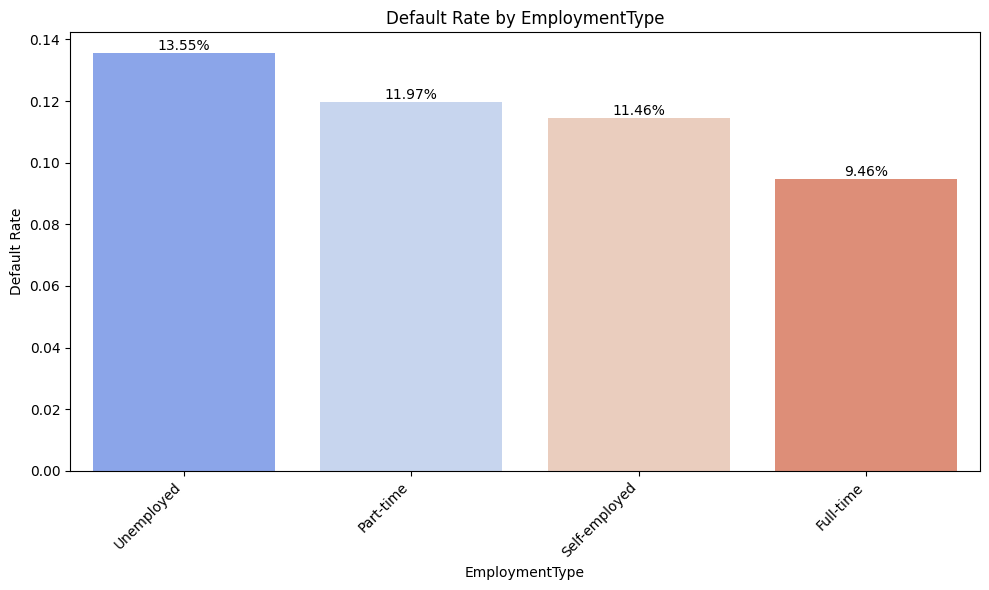

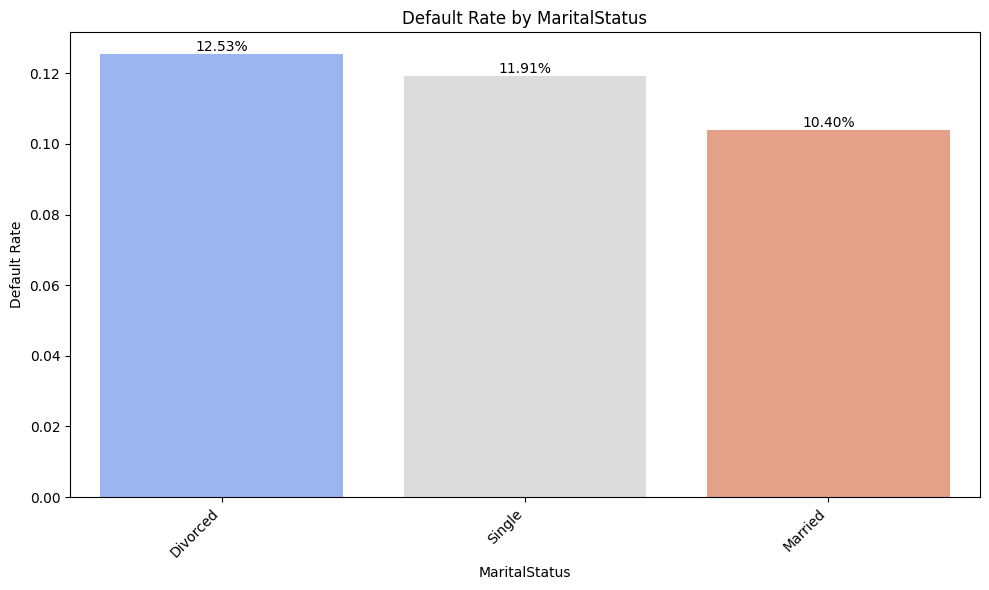

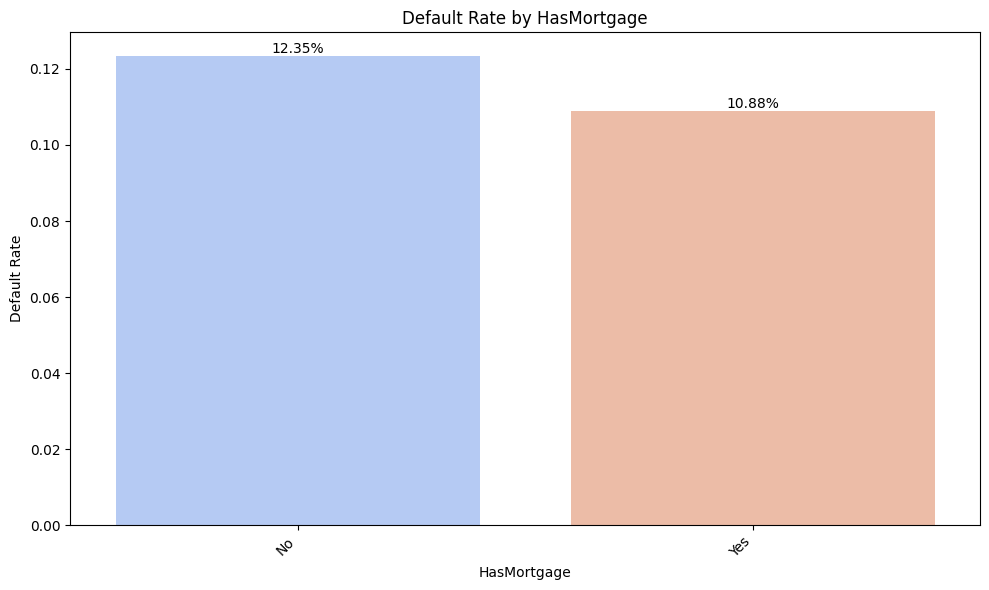

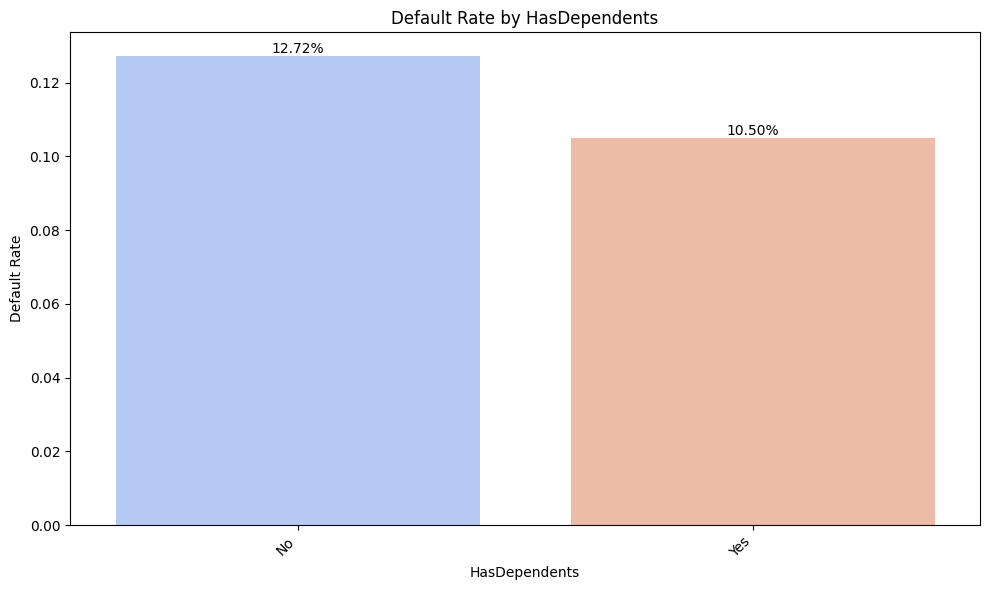

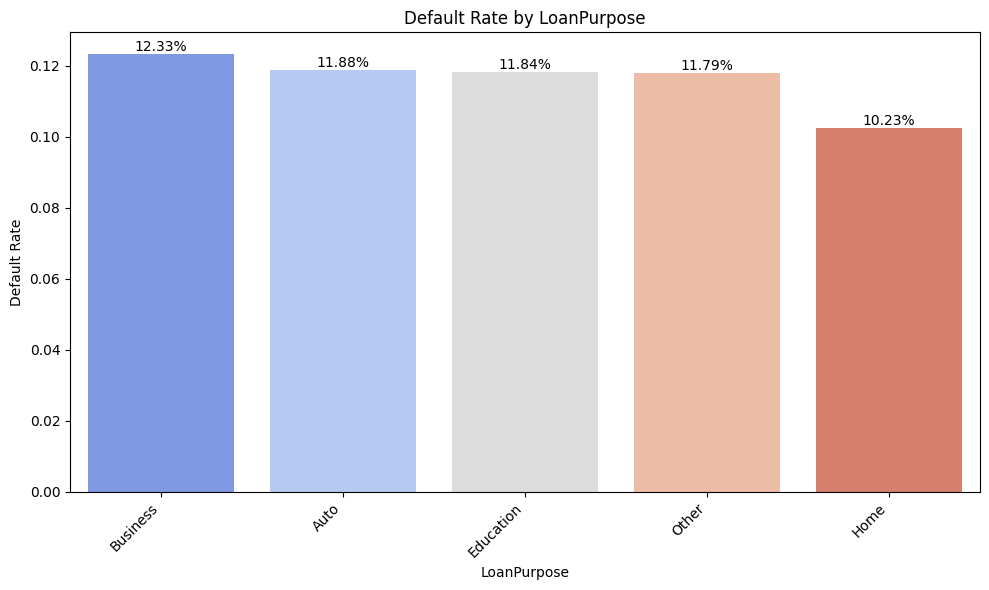

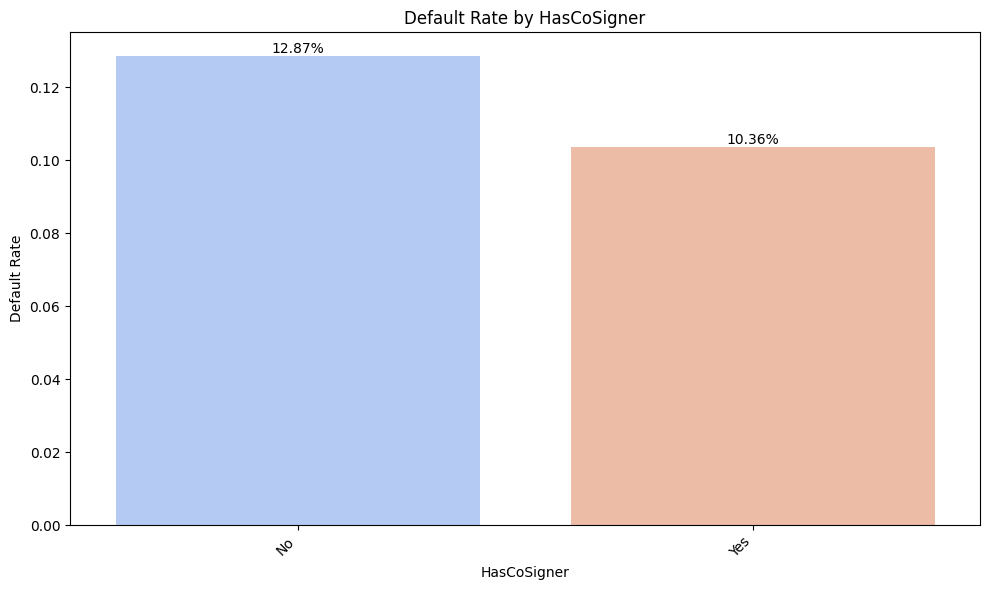

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_categorical_vs_target(df, categorical_cols, target_col):
    for col in categorical_cols:
        plt.figure(figsize=(10, 6))
        # Calculate the proportion of default for each category
        default_proportion = df.groupby(col)[target_col].mean().sort_values(ascending=False)

        ax = sns.barplot(x=default_proportion.index, y=default_proportion.values, hue=default_proportion.index, palette='coolwarm', legend=False)
        plt.title(f'Default Rate by {col}')
        plt.xlabel(col)
        plt.ylabel('Default Rate')
        plt.xticks(rotation=45, ha='right')

        # Annotate percentages on bars
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.2%}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom')
        plt.tight_layout()
        plt.show()

# Select categorical columns (excluding 'LoanID' as it's an identifier)
categorical_cols = df.drop(columns = ['LoanID']).select_dtypes(include = ['object']).columns
target_col = 'Default'

plot_categorical_vs_target(df, categorical_cols, target_col)

### Numerical Features vs. Default (Box Plots)

Now, let's create box plots for each numerical feature, comparing its distribution for customers who defaulted (`Default = 1`) versus those who did not (`Default = 0`). This will visually highlight any differences in the central tendency and spread of numerical variables across the two target categories, which can be indicative of their predictive power.

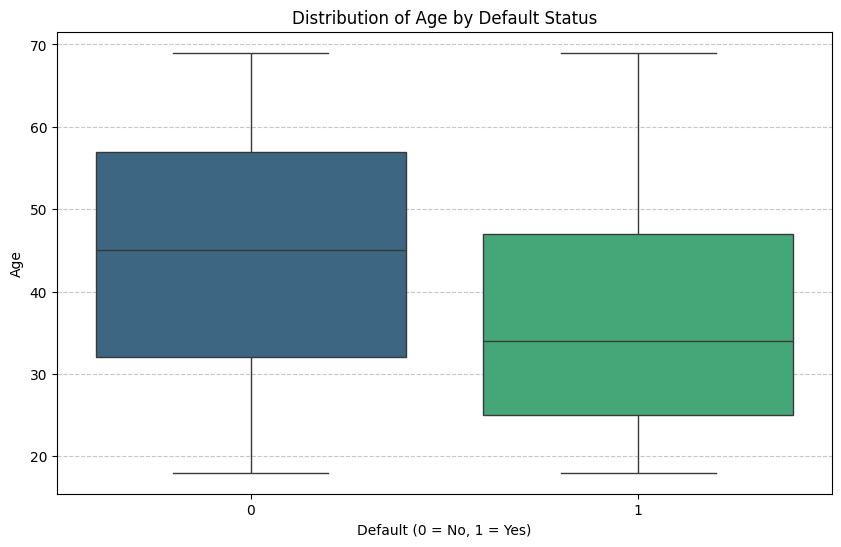

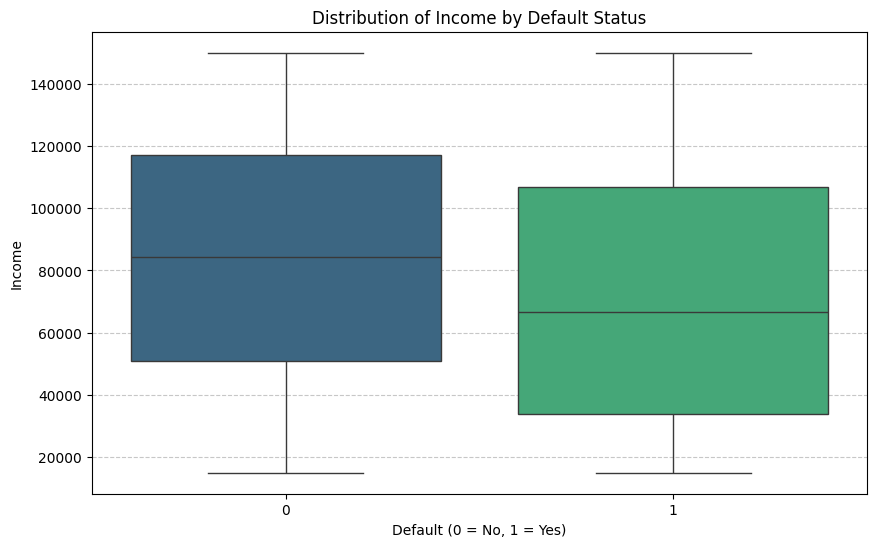

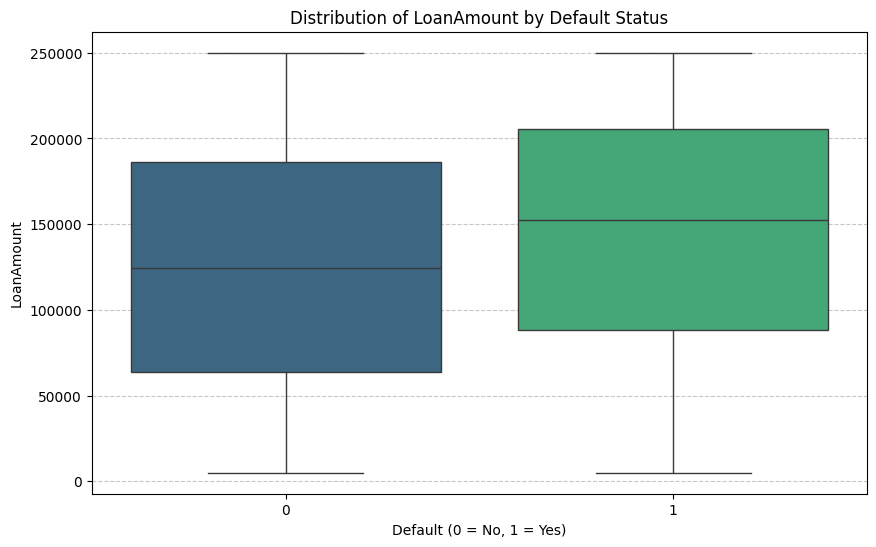

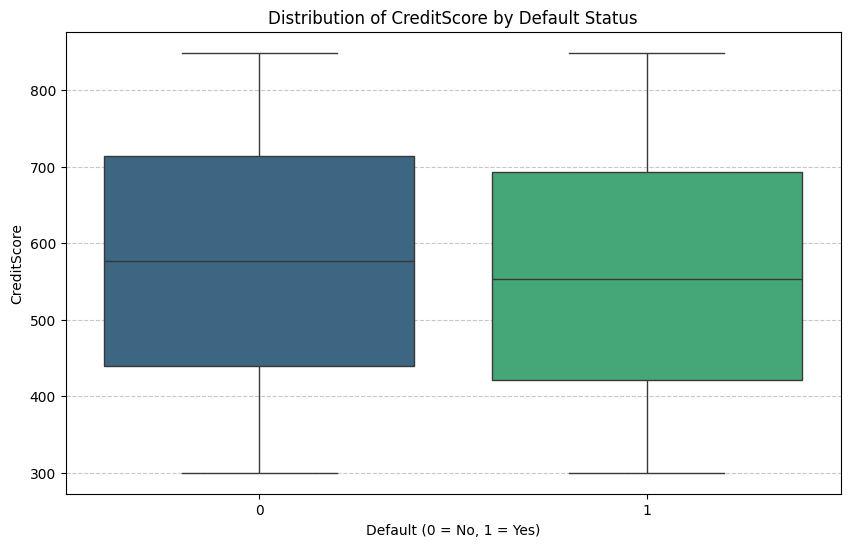

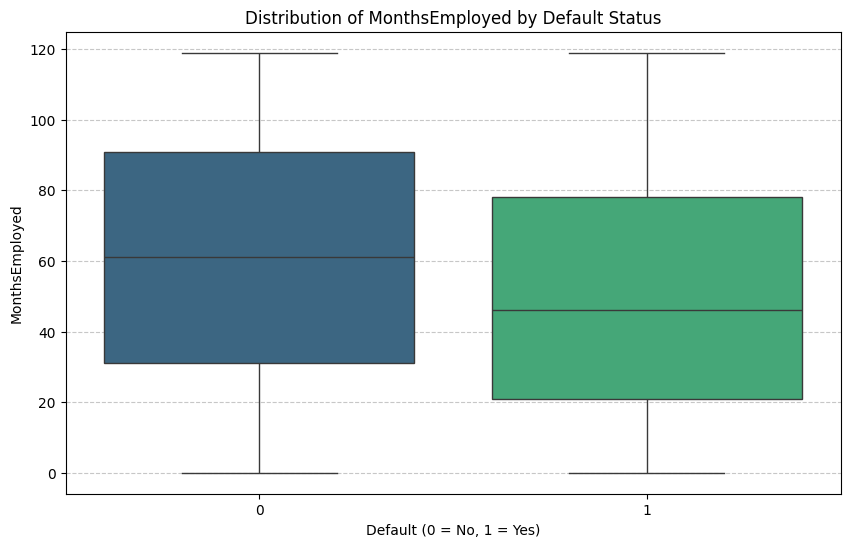

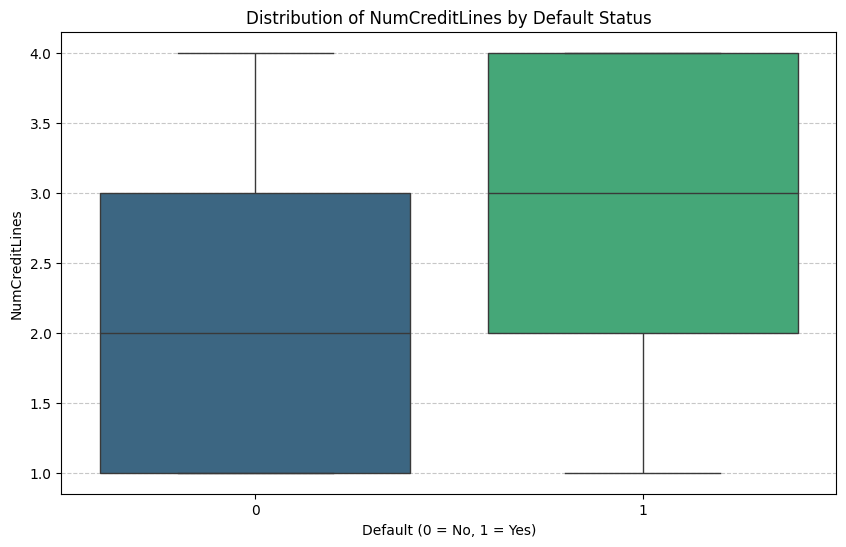

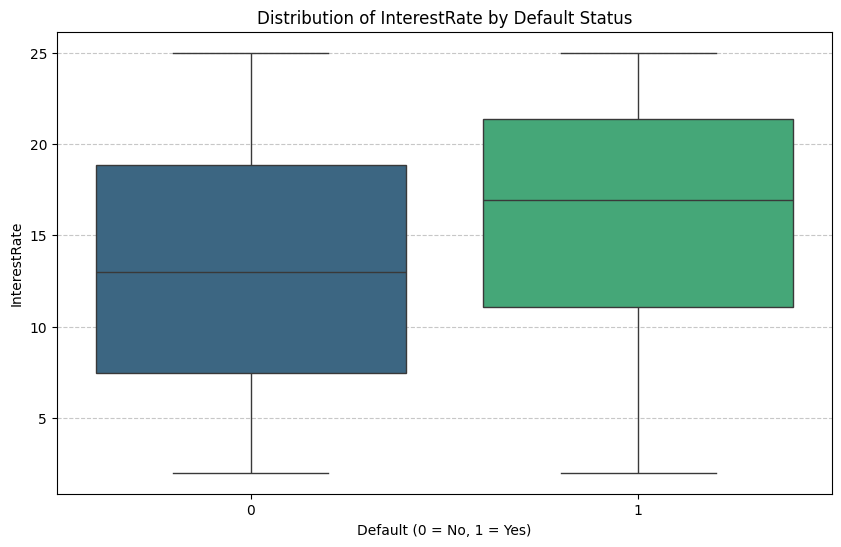

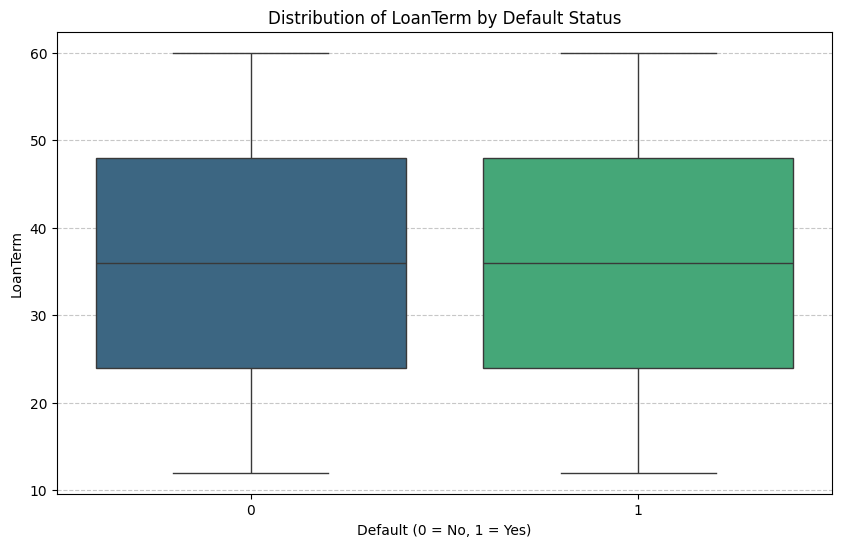

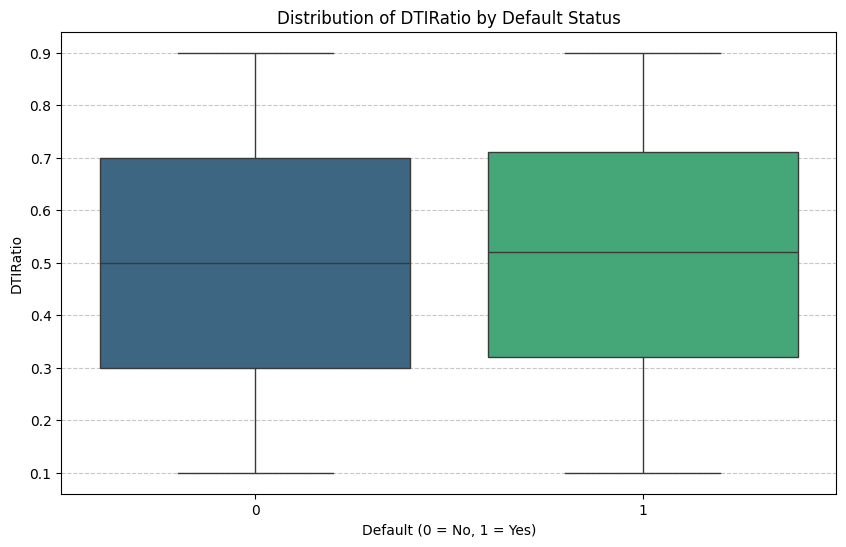

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns (excluding 'Default' itself as it's the target)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Default')

# Plot box plots for numerical columns against the 'Default' target
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Default', y=col, hue='Default', palette='viridis', legend=False)
    plt.title(f'Distribution of {col} by Default Status')
    plt.xlabel('Default (0 = No, 1 = Yes)')
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()